In [1]:
from firedrake import *

In [2]:
import matplotlib.pyplot as plt
from typing import Any

In [34]:


"""
Solve the eikonal equation |grad(u)| = 1 on the unit square with zero bcs
via latent variable proximal point (LVPP).

Reference, section 5.1 in https://doi.org/10.1016/j.cma.2025.118181.

S. Dokken, P. E. Farrell, B. Keith, I. P. A. Papadopoulos, T. M. Surowiec, 
The latent variable proximal point algorithm for variational problems with inequality constraints, 
Computer Methods in Applied Mechanics and Engineering, 2025.

"""
mesh = RectangleMesh(50, 50, 2e2, 1e2)

# Also works with degree=0.
degree = 1
Q = FunctionSpace(mesh, "RT", degree+1)
V = FunctionSpace(mesh, "DG", degree)

Z = MixedFunctionSpace([V,Q])
z = Function(Z)
u,psi = split(z)

u_old = Function(V) 
psi_old = Function(Q)

z_trial = TestFunction(Z)
v,w = split(z_trial)

alpha = Constant(1)

# See (5.5a) and (5.5b) in https://doi.org/10.1016/j.cma.2025.118181.
F = inner(psi / sqrt(1+dot(psi,psi)), w)*dx(degree=6) + inner(u, div(w))*dx
F += inner(div(psi), v)*dx - inner(div(psi_old), v)*dx + alpha*inner(Constant(1), v)*dx

# bcs =  DirichletBC(Z.sub(0), 3, "on_boundary")

# Use LU factorization
tol = 1e-4
sp = {
    "snes_monitor": None,
    "snes_linesearch_type": "l2",
    "snes_linesearch_damping": 0.5,
    "snes_rtol": tol,
    "snes_atol": tol,
    "snes_stol": tol,
    "snes_max_it": 100,
    "pc_factor_mat_solver_type": "mumps",
    "mat_mumps_icntl_14": 500,
    "snes_error_if_not_converged": True,
    "ksp_type": "preonly",
    "pc_type": "lu",
}

NLVP = NonlinearVariationalProblem(F, z)
NLVS = NonlinearVariationalSolver(NLVP, solver_parameters=sp)

u, psi = z.subfunctions
out = VTKFile("out/eikonal.pvd")
alpha.assign(1)
u.assign(1)

lvpp_max_its = 40 # max LVPP iterates
for k in range(lvpp_max_its):
    print(f"alpha = {float(alpha)}")
    u_old.assign(u)

    NLVS.solve() # solve the LVPP subproblem
    psi_old.assign(psi) # update the previous latent variable

    out.write(u) # save current iterate to disk
    
    # break if ||u^k - u^{k-1}||_{L^2} <= 1e-4
    nrm = norm(u-u_old, "L2")
    print("LVPP it: %s, Cauchy Error: %s\n"%(k,nrm))
    if nrm < 1e-4:
        break

    # update rule for proximal parameter alpha
    if float(alpha) < 10:
        alpha.assign(sqrt(2) * alpha)

alpha = 1.0
  0 SNES Function norm 1.645195023900e+02
  1 SNES Function norm 1.668853475248e+02
  2 SNES Function norm 1.671967215738e+02
  3 SNES Function norm 1.643324246482e+02
  4 SNES Function norm 1.477628532261e+02
  5 SNES Function norm 3.998518008958e+01
  6 SNES Function norm 5.735861843192e+00
  7 SNES Function norm 1.484855271294e+00
  8 SNES Function norm 2.806564699621e-01
  9 SNES Function norm 1.834176537411e-02
 10 SNES Function norm 1.120858687557e-04
LVPP it: 0, Cauchy Error: 3409.4882237093175

alpha = 1.4142135623730951
  0 SNES Function norm 2.309401076759e+02
  1 SNES Function norm 9.806786451470e+00
  2 SNES Function norm 3.977335112882e-02
  3 SNES Function norm 1.272394082965e-04
LVPP it: 1, Cauchy Error: 12.24069775674754

alpha = 2.0000000000000004
  0 SNES Function norm 3.265986323711e+02
  1 SNES Function norm 2.396797891814e+00
  2 SNES Function norm 5.046130799152e-03
LVPP it: 2, Cauchy Error: 2.763307644446768

alpha = 2.8284271247461907
  0 SNES Functi

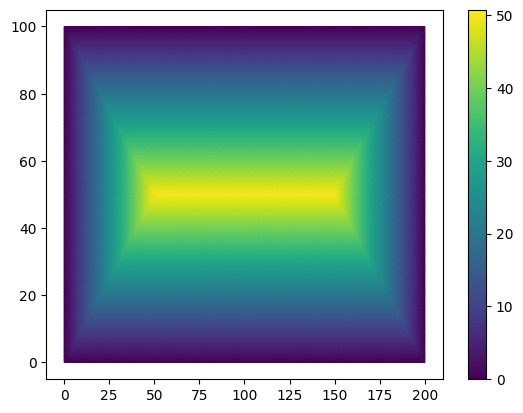

In [35]:
cm = firedrake.tripcolor(u)
plt.colorbar(cm)

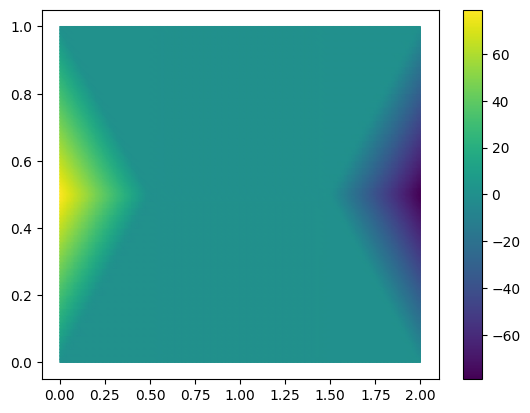

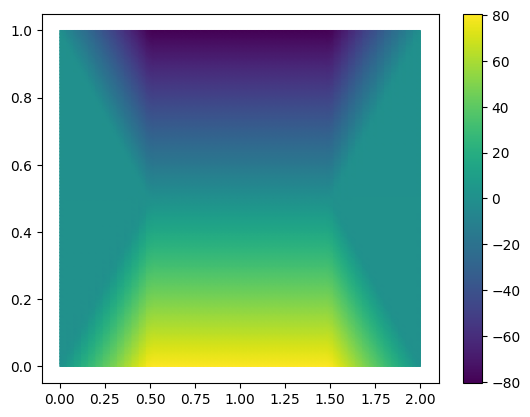

In [5]:
cm = firedrake.tripcolor(Function(V).interpolate(psi[0]))
plt.colorbar(cm)
cm = firedrake.tripcolor(Function(V).interpolate(psi[1]))
plt.colorbar(cm)